In [1]:
from wearsed.dataset.WearSEDDataset import WearSEDDataset
from wearsed.dataset.CFSDataset import CFSDataset
from wearsed.dataset.utils import to_clock

import matplotlib.pyplot as plt
import random

In [2]:
ds_mesa = WearSEDDataset(mesaid_path='../wearsed/dataset/data_ids/')
ds_cfs  = CFSDataset(cfs_id_path='../wearsed/dataset/data_ids/')

In [3]:
print(f'Length MESA: {len(ds_mesa)}')
print(f'Length CFS: {len(ds_cfs)}')

Length MESA: 1887
Length CFS: 323


In [4]:
(m_hyp, m_spo2, m_ppg), _ = ds_mesa[0]
(c_hyp, c_spo2, c_ppg), _ = ds_cfs[0]
c_ppg = c_ppg.repeat_interleave(2)

In [5]:
def comp_signal(m_s, c_s, window_start=5*60*60, window_size=10000, min_y=None):
    fig, ax = plt.subplots(1, 1, figsize=(20, 4))
    ax.plot(m_s[window_start:window_start+window_size], label='MESA', color='blue')
    ax.plot(c_s[window_start:window_start+window_size], label='CFS', color='orange')
    if min_y is not None:
        ax.set_ylim(bottom=min_y)
    ax.legend()
    plt.show()

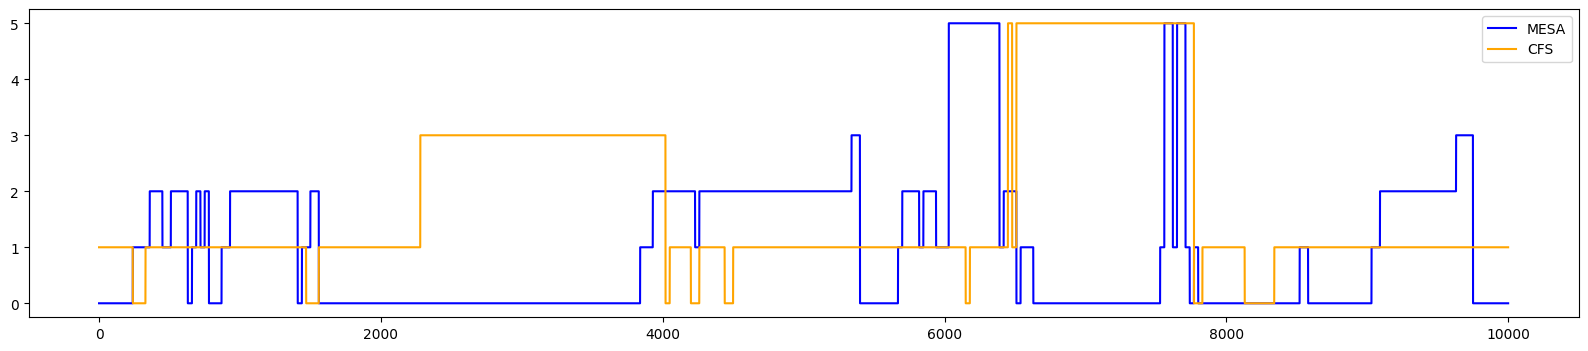

In [6]:
comp_signal(m_hyp, c_hyp)

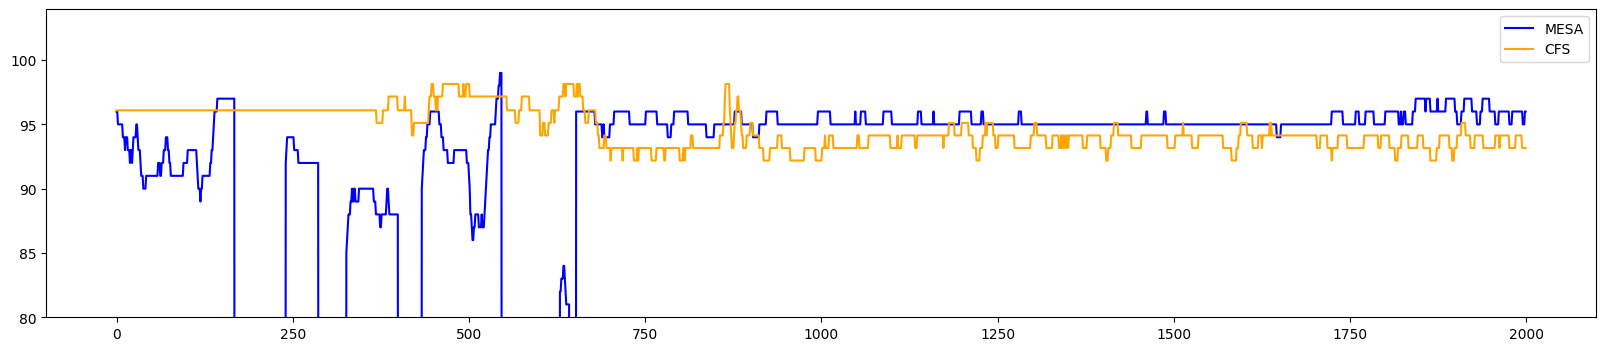

In [9]:
comp_signal(m_spo2, c_spo2, window_start=6*60*60, min_y=80, window_size=2000)

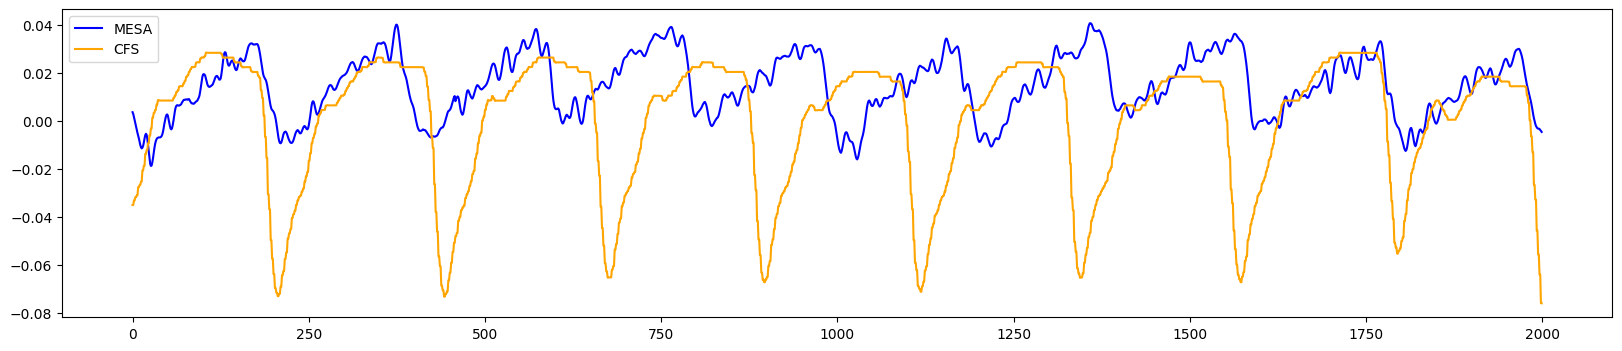

In [29]:
comp_signal(m_ppg, c_ppg, window_size=2000)

In [35]:
def comp_random_ppg(window_size=2000):
    idx_m = random.randint(0, len(ds_mesa)-1)
    idx_c = random.randint(0, len(ds_cfs)-1)

    (m_hyp, m_spo2, m_ppg), _ = ds_mesa[idx_m]
    (c_hyp, c_spo2, c_ppg), _ = ds_cfs[idx_c]
    c_ppg = c_ppg.repeat_interleave(2)

    window_start = random.randint(0, min(len(m_ppg), len(c_ppg))-window_size-1)
    print(f'Comparing MESA idx {idx_m} with CFS idx {idx_c} at time {to_clock(window_start//256)}')
    comp_signal(m_ppg, c_ppg, window_size=window_size)

Comparing MESA idx 1528 with CFS idx 273 at time 02:06:30
(7590)


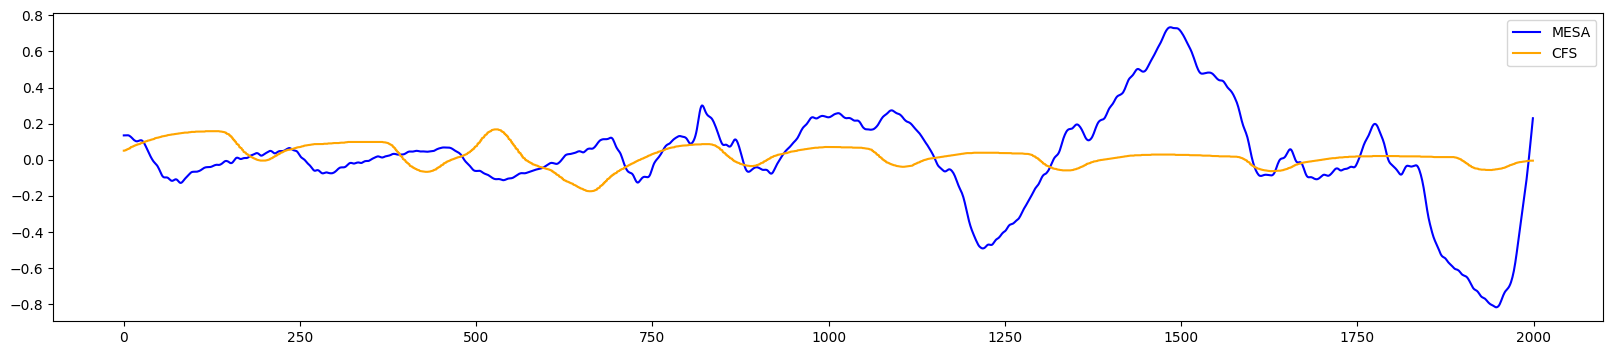

In [36]:
comp_random_ppg()

Comparing MESA idx 1722 with CFS idx 98 at time 01:03:02
(3782)


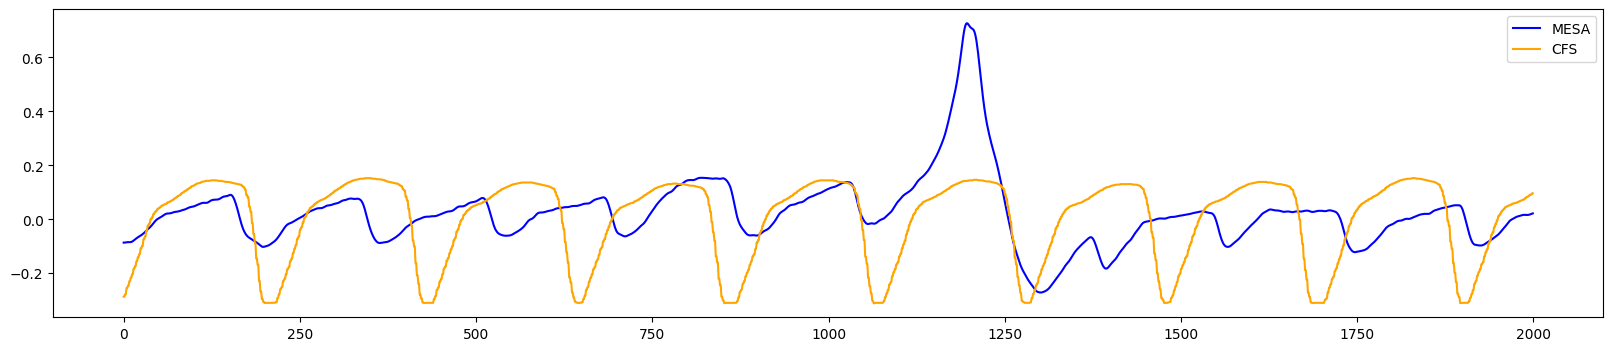

In [37]:
comp_random_ppg()

Comparing MESA idx 1159 with CFS idx 48 at time 04:19:44
(15584)


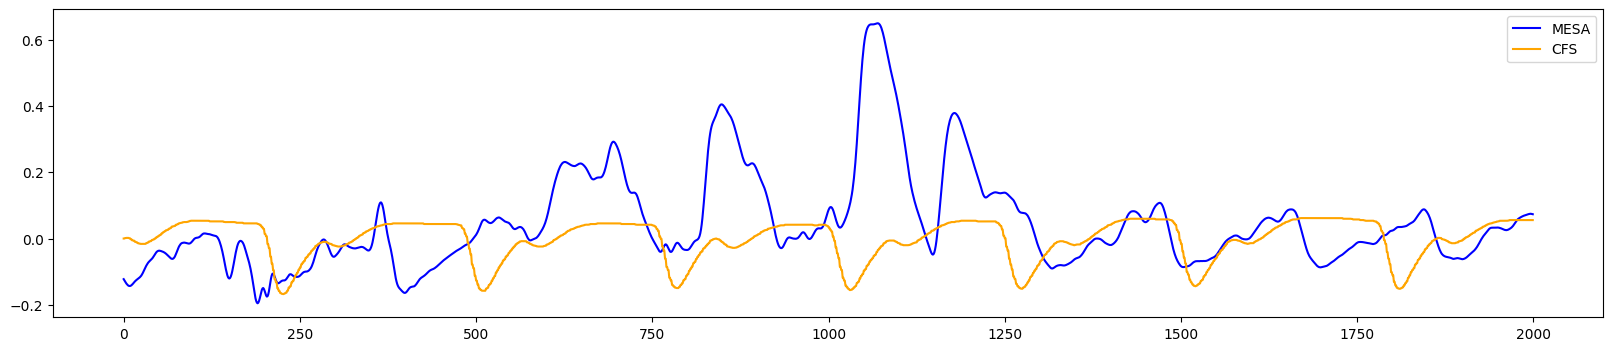

In [38]:
comp_random_ppg()

Comparing MESA idx 1479 with CFS idx 316 at time 05:21:43
(19303)


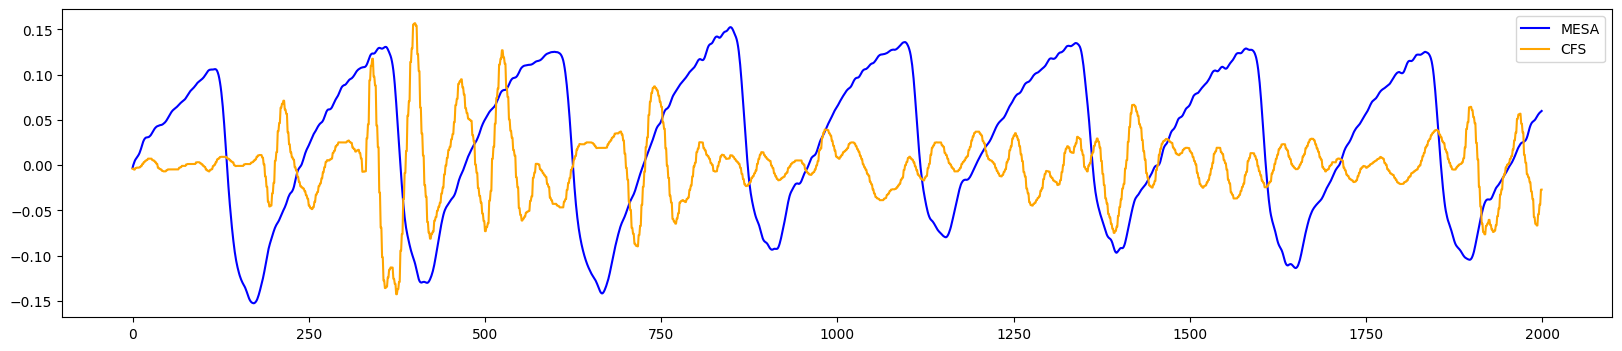

In [39]:
comp_random_ppg()

Comparing MESA idx 1414 with CFS idx 103 at time 05:07:15
(18435)


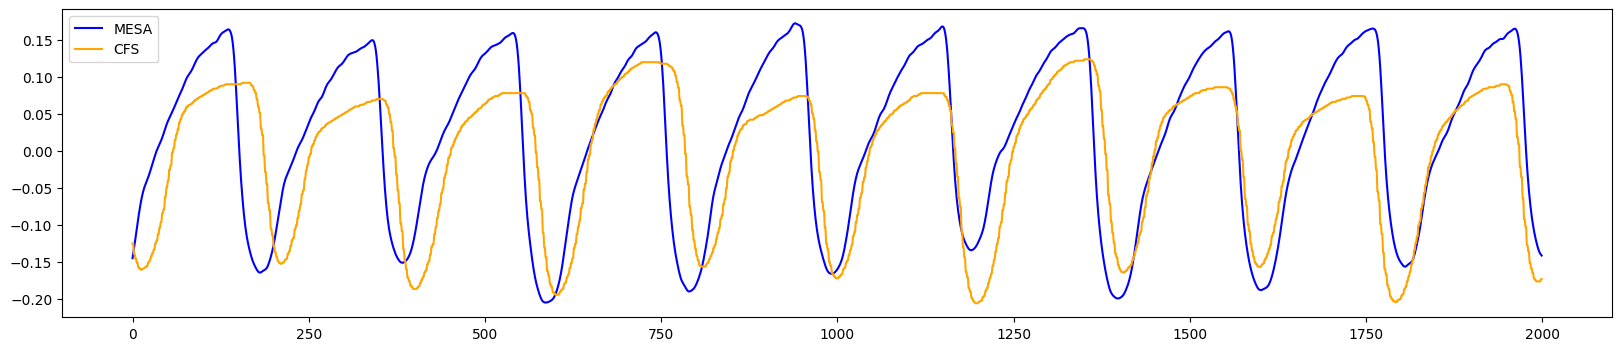

In [40]:
comp_random_ppg()

Comparing MESA idx 1451 with CFS idx 161 at time 06:04:23
(21863)


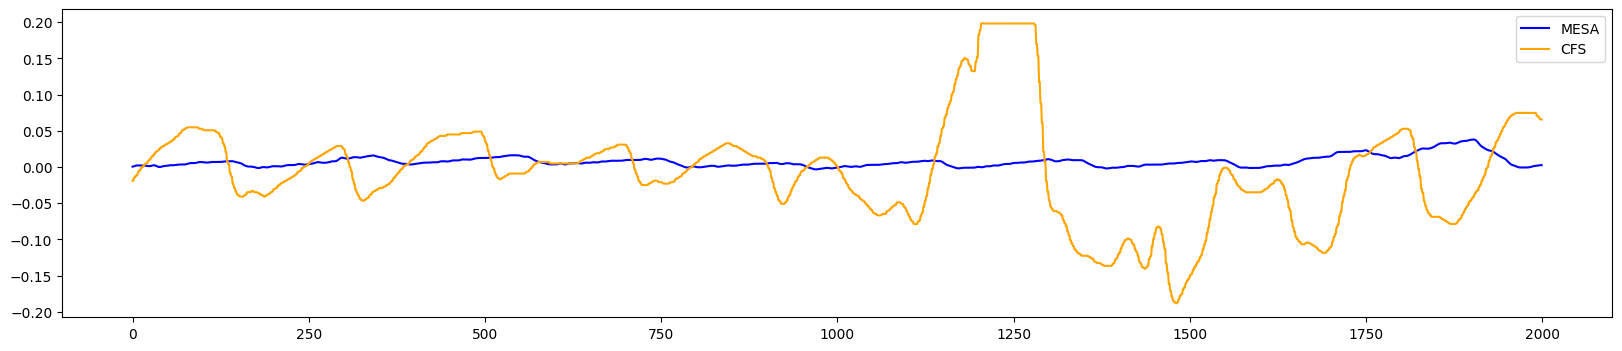

In [41]:
comp_random_ppg()

Comparing MESA idx 1515 with CFS idx 90 at time 01:48:36
(6516)


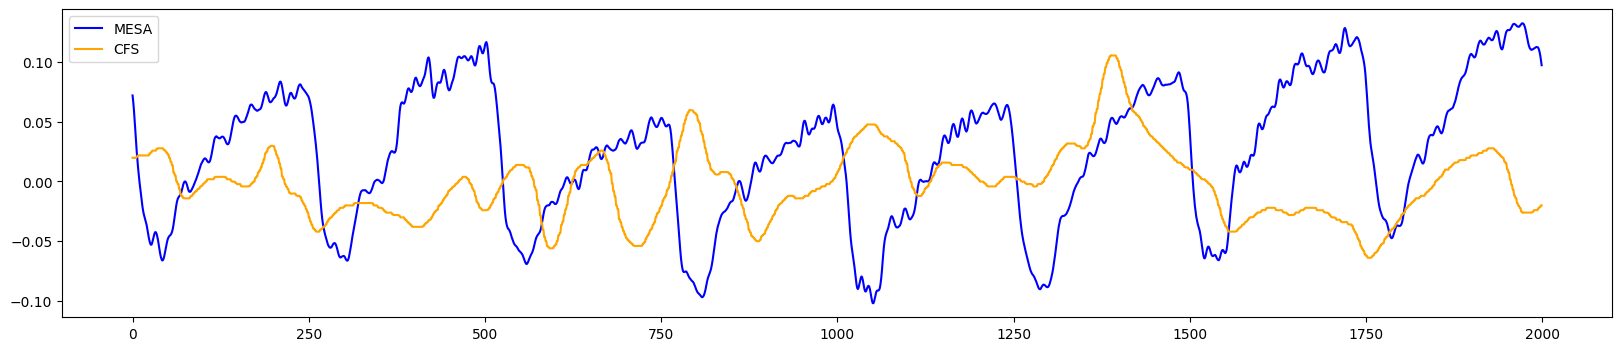

In [42]:
comp_random_ppg()

Comparing MESA idx 197 with CFS idx 230 at time 00:56:30
(3390)


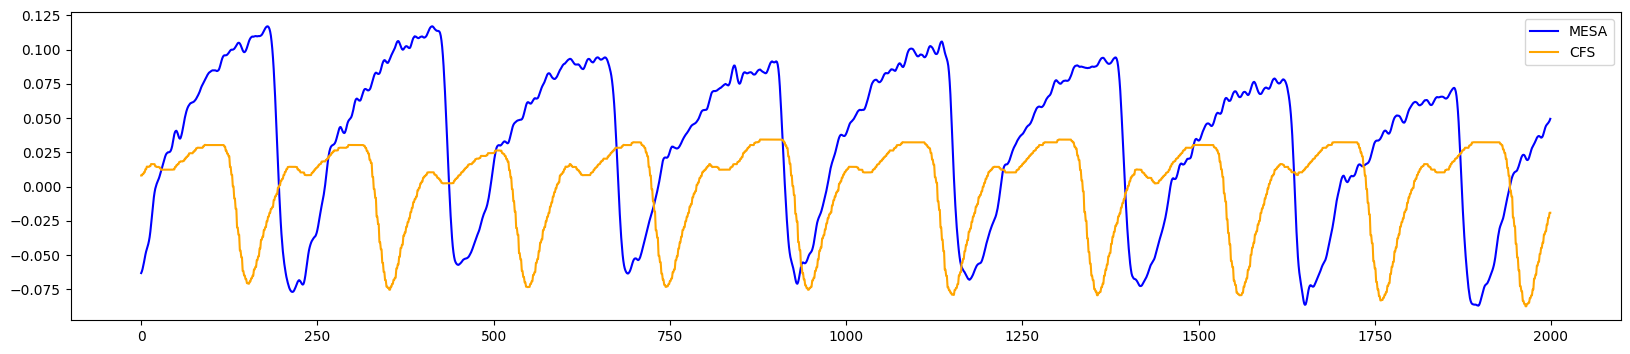

In [43]:
comp_random_ppg()

Comparing MESA idx 943 with CFS idx 38 at time 08:04:17
(29057)


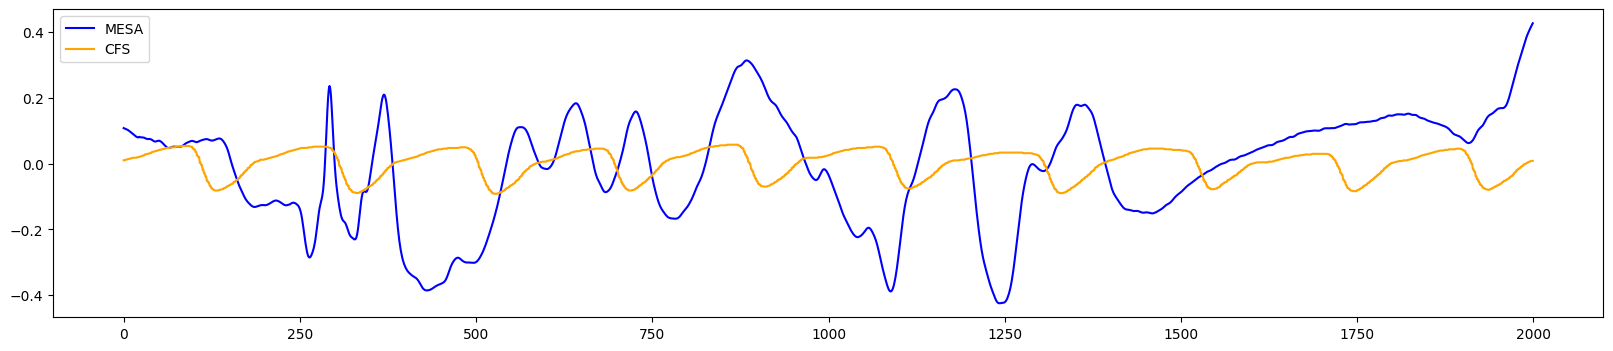

In [44]:
comp_random_ppg()